# Speech Command Model

In [5]:
import os
import zipfile
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import soundfile as sf

In [2]:
zip_path = "../data/training/Google-Speech-Commands.zip"
extract_path = "../data/training/speech_commands/"

# Only want to train on a 4-word vocabulary to save time and space
target_folders = ["yes/", "no/", "stop/", "go/"]

print("Starting targeted extraction...")

# Ensure destination folder exists
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    extracted_count = 0
    for file_info in z.infolist():
        # Check if the file belongs to one of our target folders
        if any(file_info.filename.startswith(folder) for folder in target_folders):
            z.extract(file_info, extract_path)
            extracted_count += 1

print(f"Extraction complete.. Extracted {extracted_count} audio files.")

Starting targeted extraction...
Extraction complete.. Extracted 15737 audio files.


Waveform Shape: torch.Size([1, 16000])
Sample Rate: 16000 Hz
Spectrogram Shape: torch.Size([1, 64, 32])


C:\Users\Eric\anaconda3\envs\multimodal-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


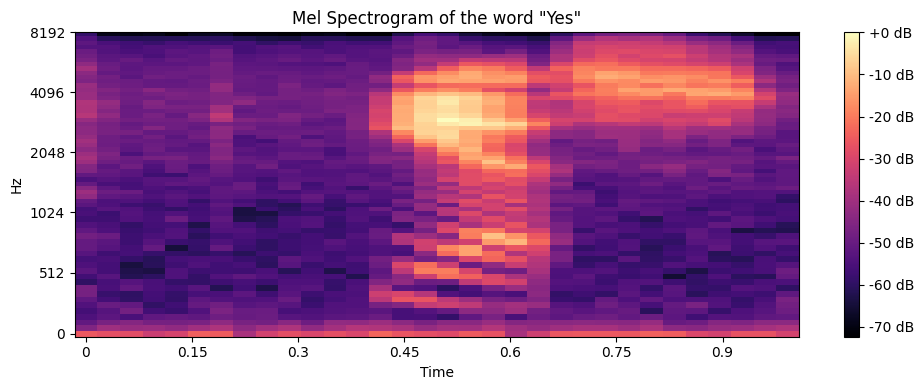

In [6]:
# Point strictly to the unzipped directory containing the word folders
base_path = "../data/training/speech_commands/"
sample_word_dir = os.path.join(base_path, "yes")

# Check if the path exists before trying to read it
if not os.path.exists(sample_word_dir):
    raise FileNotFoundError(f"Cannot find the unzipped directory at: {os.path.abspath(sample_word_dir)}")

# Grab the first .wav file in the 'yes' folder
sample_files = [f for f in os.listdir(sample_word_dir) if f.endswith('.wav')]
sample_audio_path = os.path.join(sample_word_dir, sample_files[0])

# BYPASS TORCHAUDIO: Load the audio natively using soundfile
# dtype='float32' ensures it matches what neural networks expect..
audio_data, sample_rate = sf.read(sample_audio_path, dtype='float32')

# Soundfile returns a 1D array for mono audio, but PyTorch expects (channels, frames)
if audio_data.ndim == 1:
    audio_data = np.expand_dims(audio_data, axis=0) # Add channel dimension
elif audio_data.ndim == 2:
    audio_data = audio_data.T # Transpose if stereo

# Convert the numpy array directly into a PyTorch tensor
waveform = torch.from_numpy(audio_data)

print(f"Waveform Shape: {waveform.shape}")
print(f"Sample Rate: {sample_rate} Hz")

# Convert the raw waveform into a Mel Spectrogram
mel_spectrogram_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_mels=64,
    n_fft=1024,
    hop_length=512
)

mel_spec = mel_spectrogram_transform(waveform)
print(f"Spectrogram Shape: {mel_spec.shape}")

# Visualize it
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    librosa.power_to_db(mel_spec[0].numpy(), ref=np.max), 
    y_axis='mel', 
    x_axis='time', 
    sr=sample_rate, 
    hop_length=512
)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram of the word "Yes"')
plt.tight_layout()
plt.show()

# Speech Command Dataset

In [7]:
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as transforms

In [8]:
class SpeechCommandsDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        
        # Define our 4-word vocabulary and map them to integers for the neural network
        self.classes = ["yes", "no", "stop", "go"]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.filepaths = []
        self.labels = []
        
        # Scan the directories and build a list of all audio files
        for cls_name in self.classes:
            cls_dir = os.path.join(base_dir, cls_name)
            if not os.path.exists(cls_dir):
                print(f"Warning: Directory {cls_dir} not found. Skipping.")
                continue
                
            for filename in os.listdir(cls_dir):
                if filename.endswith('.wav'):
                    self.filepaths.append(os.path.join(cls_dir, filename))
                    self.labels.append(self.class_to_idx[cls_name])
                    
        print(f"Loaded {len(self.filepaths)} audio files across {len(self.classes)} classes.")

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.labels[idx]
        
        # Load audio using soundfile workaround
        audio_data, sample_rate = sf.read(filepath, dtype='float32')
        
        # Handle stereo to mono conversion if necessary
        if audio_data.ndim > 1:
            audio_data = audio_data.mean(axis=1)
            
        waveform = torch.from_numpy(audio_data).unsqueeze(0) # Add channel dimension
        
        # Force all waveforms to exactly 16,000 samples (1 second)
        target_length = 16000
        current_length = waveform.shape[1]
        
        if current_length > target_length:
            # Truncate
            waveform = waveform[:, :target_length]
        elif current_length < target_length:
            # Pad with silence (zeros)
            padding = torch.zeros(1, target_length - current_length)
            waveform = torch.cat((waveform, padding), dim=1)
            
        # Apply the spectrogram transform if provided
        if self.transform:
            waveform = self.transform(waveform)
            
        return waveform, label

# Test Dataset

In [9]:
base_path = "../data/training/speech_commands/"

# Define the exact same transform we used earlier
mel_transform = transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=64,
    n_fft=1024,
    hop_length=512
)

# Instantiate the dataset
dataset = SpeechCommandsDataset(base_dir=base_path, transform=mel_transform)

# Instantiate the DataLoader (this batches the data for the GPU/CPU)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Grab one batch to verify the plumbing works
features, labels = next(iter(dataloader))
print(f"Batch Features Shape: {features.shape}")
print(f"Batch Labels Shape: {labels.shape}")

Loaded 15737 audio files across 4 classes.
Batch Features Shape: torch.Size([32, 1, 64, 32])
Batch Labels Shape: torch.Size([32])


# CNN Architecture

In [10]:
import torch.nn as nn
import torch.nn.functional as F

In [11]:
class KeywordSpotterCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(KeywordSpotterCNN, self).__init__()
        
        # Find basic shapes and lines in the spectrogram
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Shape after Block 1: [Batch, 16, 32, 16]
        
        # Find complex audio patterns
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # High-level feature extraction
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Flatten the 3D tensor into a 1D vector for the Dense layers
        # 64 channels * 8 height * 4 width = 2048
        
        # Fully Connected (Dense) layers to make the final decision
        self.fc1 = nn.Linear(64 * 8 * 4, 128)
        self.dropout = nn.Dropout(0.3) # Prevent overfitting
        self.fc2 = nn.Linear(128, num_classes) # Final output layer (4 neurons)

    def forward(self, x):
        # Pass input through Convolutional blocks
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1) 
        
        # Pass through Dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Test Model Architecture

In [12]:
# Initialize the model
model = KeywordSpotterCNN(num_classes=4)

# Pass our batch of 32 spectrograms from the previous cell into the untrained model
output = model(features)

print(f"Model Output Shape: {output.shape}")
print(f"Sample prediction for the first audio file (Raw Logits): {output[0].detach().numpy()}")

Model Output Shape: torch.Size([32, 4])
Sample prediction for the first audio file (Raw Logits): [-0.21000972 -0.67559534  0.4198805   0.2605307 ]


# Training Run - 5 Epochs

In [13]:
import torch.optim as optim

In [14]:
# Move model to the GPU if have one, otherwise use the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# The Loss Function: Measures how wrong the model's guesses are
criterion = nn.CrossEntropyLoss()

# The Optimizer 
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
print(f"Starting training on {device}...")

# The Outer Loop
for epoch in range(num_epochs):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    # The Inner Loop
    for i, (inputs, labels) in enumerate(dataloader):
        # Move data to the same device as the model
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Clear out the old math from the previous batch
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward Pass 
        loss.backward()
        
        # Optimize
        optimizer.step()
        
        # Tracking progress
        running_loss += loss.item()
        
        # Find which of the 4 words had the highest score
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Print progress every 100 batches
        if (i + 1) % 100 == 0:
            current_loss = running_loss / 100
            current_acc = (correct / total) * 100
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(dataloader)}], Loss: {current_loss:.4f}, Accuracy: {current_acc:.2f}%")
            running_loss = 0.0
            
    # Print the final score at the end of the epoch
    epoch_acc = (correct / total) * 100
    print(f"=== End of Epoch {epoch+1} | Overall Accuracy: {epoch_acc:.2f}% ===\n")

print("Training Complete..")

Starting training on cpu...
Epoch [1/5], Batch [100/492], Loss: 2.9436, Accuracy: 42.00%
Epoch [1/5], Batch [200/492], Loss: 1.1881, Accuracy: 48.91%
Epoch [1/5], Batch [300/492], Loss: 1.1013, Accuracy: 52.94%
Epoch [1/5], Batch [400/492], Loss: 1.0871, Accuracy: 54.80%
=== End of Epoch 1 | Overall Accuracy: 57.02% ===

Epoch [2/5], Batch [100/492], Loss: 0.7665, Accuracy: 72.53%
Epoch [2/5], Batch [200/492], Loss: 0.7483, Accuracy: 72.52%
Epoch [2/5], Batch [300/492], Loss: 0.7145, Accuracy: 73.06%
Epoch [2/5], Batch [400/492], Loss: 0.6588, Accuracy: 73.78%
=== End of Epoch 2 | Overall Accuracy: 74.42% ===

Epoch [3/5], Batch [100/492], Loss: 0.5396, Accuracy: 79.56%
Epoch [3/5], Batch [200/492], Loss: 0.6004, Accuracy: 79.06%
Epoch [3/5], Batch [300/492], Loss: 0.6189, Accuracy: 78.46%
Epoch [3/5], Batch [400/492], Loss: 0.6694, Accuracy: 77.79%
=== End of Epoch 3 | Overall Accuracy: 78.27% ===

Epoch [4/5], Batch [100/492], Loss: 0.4855, Accuracy: 82.06%
Epoch [4/5], Batch [200/49

In [15]:
# Ensure models directory exists
models_dir = "../models/"
os.makedirs(models_dir, exist_ok=True)

# Define save path
save_path = os.path.join(models_dir, "custom_kws.pth")

# Save only the weights
torch.save(model.state_dict(), save_path)
print(f"Model weights successfully saved to: {save_path}")

Model weights successfully saved to: ../models/custom_kws.pth
